In [1]:
# ============================================================
# PHASE 5 — FTL vs CARTING FRAMEWORK + STRATEGY MEMO DATA
# ============================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [4]:
# ── Load Phase 4 ─────────────────────────────────────────────
with open('phase4_results.pkl', 'rb') as f:
    data = pickle.load(f)

trip_agg        = data['trip_agg_p4']   # has graph features
corridor_stats  = data['corridor_stats'] if 'corridor_stats' in data else None
hub_df          = data['hub_df'] if 'hub_df' in data else None
G               = data['G'] if 'G' in data else None
baseline_mae    = data['best_graph_mae']
results_df      = data['results_df']

print(f"✅ Phase 4 loaded")
print(f"trip_agg: {trip_agg.shape}")

# If corridor_stats/hub_df not in phase4, load from phase3
if corridor_stats is None:
    with open('phase3_checkpoint.pkl', 'rb') as f:
        p3 = pickle.load(f)
    corridor_stats = p3['corridor_stats']
    hub_df         = p3['hub_df']
    G              = p3['G']
    print("corridor_stats/hub_df loaded from phase3_checkpoint")

THRESHOLD_SEVERE = np.percentile(trip_agg['trip_delay_ratio'].dropna(), 90)


✅ Phase 4 loaded
trip_agg: (14804, 62)
corridor_stats/hub_df loaded from phase3_checkpoint


In [5]:
# ── PART 1: FTL vs CARTING DECISION FRAMEWORK ────────────────
print("\n" + "="*55)
print("PART 1 — FTL vs CARTING DECISION FRAMEWORK")
print("="*55)

# Find corridors that have BOTH FTL and Carting data
corridor_ftl = corridor_stats[corridor_stats['route_type']=='FTL'][
    ['source_center','destination_center','median_delay_ratio',
     'avg_actual_time','sla_severe_rate','avg_distance','trip_count']
].rename(columns={
    'median_delay_ratio':'ftl_delay',
    'avg_actual_time':   'ftl_time',
    'sla_severe_rate':   'ftl_severe_rate',
    'trip_count':        'ftl_trips'
})

corridor_cart = corridor_stats[corridor_stats['route_type']=='Carting'][
    ['source_center','destination_center','median_delay_ratio',
     'avg_actual_time','sla_severe_rate','avg_distance','trip_count']
].rename(columns={
    'median_delay_ratio':'cart_delay',
    'avg_actual_time':   'cart_time',
    'sla_severe_rate':   'cart_severe_rate',
    'trip_count':        'cart_trips'
})

comparison = corridor_ftl.merge(
    corridor_cart,
    on=['source_center','destination_center'],
    how='inner'
)

print(f"Corridors with both FTL and Carting data: {len(comparison)}")

# Target: 1 = FTL is better (lower delay), 0 = Carting is better
comparison['ftl_better']        = (comparison['ftl_delay'] < comparison['cart_delay']).astype(int)
comparison['time_saved_by_ftl'] = comparison['cart_time'] - comparison['ftl_time']
comparison['delay_diff']        = comparison['cart_delay'] - comparison['ftl_delay']

print(f"\nCorridors where FTL is faster: {comparison['ftl_better'].mean():.1%}")
print(f"Avg time saved when FTL better: "
      f"{comparison[comparison['ftl_better']==1]['time_saved_by_ftl'].mean():.1f} min")
print(f"Avg time saved when Carting better: "
      f"{comparison[comparison['ftl_better']==0]['time_saved_by_ftl'].mean():.1f} min")

# Add graph features to comparison
hub_index = hub_df.set_index('facility')
comparison['src_betweenness'] = (comparison['source_center'].astype(str)
                                  .map(hub_index['betweenness']).fillna(0))
comparison['dst_betweenness'] = (comparison['destination_center'].astype(str)
                                  .map(hub_index['betweenness']).fillna(0))
comparison['src_bottleneck']  = (comparison['source_center'].astype(str)
                                  .map(hub_index['bottleneck_score']).fillna(0))
comparison['dst_bottleneck']  = (comparison['destination_center'].astype(str)
                                  .map(hub_index['bottleneck_score']).fillna(0))
comparison['avg_distance_x']  = comparison.get('avg_distance_x',
                                 comparison.get('avg_distance', 0))

# Feature set for decision model
ftl_features = [
    'src_betweenness', 'dst_betweenness',
    'src_bottleneck',  'dst_bottleneck',
    'ftl_severe_rate', 'cart_severe_rate',
    'avg_distance_x',  'ftl_trips',
]
ftl_features = [f for f in ftl_features if f in comparison.columns]

X_ftl = comparison[ftl_features].fillna(0)
y_ftl = comparison['ftl_better']

print(f"\nFTL decision model features: {ftl_features}")
print(f"Class balance — FTL better: {y_ftl.mean():.1%}  "
      f"Carting better: {1-y_ftl.mean():.1%}")


# ── Decision Tree (interpretable rules) ──────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ftl, y_ftl, test_size=0.25, random_state=42
)

# Decision tree — max_depth=4 keeps rules readable for ops team
dt = DecisionTreeClassifier(max_depth=4, random_state=42,
                              min_samples_leaf=3)
dt.fit(X_tr, y_tr)
dt_pred = dt.predict(X_te)

print("\n=== DECISION TREE — FTL vs CARTING ===")
print(classification_report(y_te, dt_pred,
                             target_names=['Carting better','FTL better']))

# Human-readable rules — this is what goes in the strategy memo
print("\nDecision rules (for operations team):")
rules = export_text(dt, feature_names=ftl_features, max_depth=4)
print(rules)

# Logistic Regression — for probability scoring
scaler_ftl = StandardScaler()
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(scaler_ftl.fit_transform(X_tr), y_tr)
lr_pred = lr.predict(scaler_ftl.transform(X_te))

print("\n=== LOGISTIC REGRESSION — FTL vs CARTING ===")
print(classification_report(y_te, lr_pred,
                             target_names=['Carting better','FTL better']))

coef_df = pd.DataFrame({
    'feature':     ftl_features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print("\nCoefficients (positive = favours FTL):")
print(coef_df.to_string(index=False))


PART 1 — FTL vs CARTING DECISION FRAMEWORK
Corridors with both FTL and Carting data: 23

Corridors where FTL is faster: 43.5%
Avg time saved when FTL better: -22.7 min
Avg time saved when Carting better: -51.3 min

FTL decision model features: ['src_betweenness', 'dst_betweenness', 'src_bottleneck', 'dst_bottleneck', 'ftl_severe_rate', 'cart_severe_rate', 'avg_distance_x', 'ftl_trips']
Class balance — FTL better: 43.5%  Carting better: 56.5%

=== DECISION TREE — FTL vs CARTING ===
                precision    recall  f1-score   support

Carting better       0.67      0.67      0.67         3
    FTL better       0.67      0.67      0.67         3

      accuracy                           0.67         6
     macro avg       0.67      0.67      0.67         6
  weighted avg       0.67      0.67      0.67         6


Decision rules (for operations team):
|--- ftl_severe_rate <= 0.04
|   |--- class: 1
|--- ftl_severe_rate >  0.04
|   |--- ftl_trips <= 4.50
|   |   |--- dst_bottleneck <= 0

In [6]:

# ── PART 2: QUANTIFY TIME-COST TRADEOFF ──────────────────────
print("\n" + "="*55)
print("PART 2 — TIME-COST TRADEOFF QUANTIFICATION")
print("="*55)

# Segment corridors by distance profile
comparison['distance_bucket'] = pd.cut(
    comparison['avg_distance_x'],
    bins=[0, 100, 300, 600, 10000],
    labels=['Short (<100km)', 'Medium (100-300km)',
            'Long (300-600km)', 'Very Long (>600km)']
)

tradeoff = comparison.groupby('distance_bucket', observed=True).agg(
    n_corridors       =('ftl_better',       'count'),
    pct_ftl_better    =('ftl_better',        'mean'),
    avg_time_diff     =('time_saved_by_ftl', 'mean'),
    avg_delay_diff    =('delay_diff',         'mean'),
).round(3)

print("\nFTL vs Carting by distance profile:")
print(tradeoff.to_string())
print("\nInterpretation:")
print("  positive avg_time_diff = FTL saves time on average for this distance band")
print("  positive avg_delay_diff = Carting has higher delay ratio")


PART 2 — TIME-COST TRADEOFF QUANTIFICATION

FTL vs Carting by distance profile:
                 n_corridors  pct_ftl_better  avg_time_diff  avg_delay_diff
distance_bucket                                                            
Short (<100km)            23           0.435        -38.867          -0.391

Interpretation:
  positive avg_time_diff = FTL saves time on average for this distance band
  positive avg_delay_diff = Carting has higher delay ratio


In [7]:
# ── PART 3: REVENUE AT RISK ───────────────────────────────────
print("\n" + "="*55)
print("PART 3 — REVENUE AT RISK CALCULATION")
print("="*55)

total_trips    = len(trip_agg)
severe_trips   = trip_agg['is_trip_severe'].sum()
severe_rate    = trip_agg['is_trip_severe'].mean()

# Conservative assumptions — state clearly
AVG_SHIPMENT_VALUE = 2000    # INR — conservative avg B2C shipment
PENALTY_RATE       = 0.05    # 5% SLA penalty per breach
ANNUAL_MULTIPLIER  = 12      # scale sample to annual estimate
RECOVERY_RATE      = 0.50    # conservative: 50% recoverable by fixing top hubs

annual_severe    = severe_trips * ANNUAL_MULTIPLIER
revenue_at_risk  = annual_severe * AVG_SHIPMENT_VALUE * PENALTY_RATE

# Top 3 hub contribution
top3 = hub_df.nlargest(3, 'bottleneck_score')
top3_severe_contrib = top3['outgoing_severe_rate'].mean()
top3_revenue_risk   = revenue_at_risk * top3_severe_contrib
potential_recovery  = top3_revenue_risk * RECOVERY_RATE

print(f"Assumptions:")
print(f"  Avg shipment value:  ₹{AVG_SHIPMENT_VALUE:,}")
print(f"  SLA penalty rate:    {PENALTY_RATE:.0%} per breach")
print(f"  Annual multiplier:   {ANNUAL_MULTIPLIER}x (sample → annual)")
print(f"  Recovery rate:       {RECOVERY_RATE:.0%} (conservative)")
print(f"\nResults:")
print(f"  Total trips (sample):          {total_trips:,}")
print(f"  Severe delayed trips:          {severe_trips:,} ({severe_rate:.1%})")
print(f"  Est. annual severe trips:      {annual_severe:,}")
print(f"  Total revenue at risk (annual):₹{revenue_at_risk/1e7:.2f} Cr")
print(f"  Top 3 hub contribution:        {top3_severe_contrib:.1%}")
print(f"  Revenue at risk via top 3:     ₹{top3_revenue_risk/1e7:.2f} Cr")
print(f"  Potential recovery:            ₹{potential_recovery/1e6:.0f}L annually")
print(f"\nTop 3 bottleneck hubs:")
print(top3[['facility','bottleneck_score','outgoing_severe_rate','trip_volume']].to_string())



PART 3 — REVENUE AT RISK CALCULATION
Assumptions:
  Avg shipment value:  ₹2,000
  SLA penalty rate:    5% per breach
  Annual multiplier:   12x (sample → annual)
  Recovery rate:       50% (conservative)

Results:
  Total trips (sample):          14,804
  Severe delayed trips:          1,764 (11.9%)
  Est. annual severe trips:      21,168
  Total revenue at risk (annual):₹0.21 Cr
  Top 3 hub contribution:        37.4%
  Revenue at risk via top 3:     ₹0.08 Cr
  Potential recovery:            ₹0L annually

Top 3 bottleneck hubs:
         facility  bottleneck_score  outgoing_severe_rate  trip_volume
25   IND000000ACB          0.720099              0.066997         1848
12   IND562132AAA          0.514591              0.055410         1366
628  IND400072AAJ          0.320399              1.000000           53


In [8]:
# ── PART 4: STRATEGY MEMO DATA ────────────────────────────────
print("\n" + "="*55)
print("PART 4 — STRATEGY MEMO FINDINGS")
print("="*55)

# Hub intervention recommendations
hub_interventions = hub_df.nlargest(5, 'bottleneck_score').copy()
hub_interventions['recommended_action'] = hub_interventions.apply(
    lambda r: (
        'Capacity upgrade — high volume, high centrality'
        if r['trip_volume'] > 500 and r['betweenness'] > 0.05
        else 'Route diversification — chronic delay, low volume'
        if r['outgoing_severe_rate'] > 0.5
        else 'Monitoring + SLA alert — moderate risk'
    ), axis=1
)
hub_interventions['estimated_sla_breach_contribution'] = (
    hub_interventions['outgoing_severe_rate'] *
    hub_interventions['trip_volume'] /
    (hub_df['outgoing_severe_rate'] * hub_df['trip_volume']).sum()
)

print("\nTop 5 Hub Interventions:")
print(hub_interventions[
    ['facility','bottleneck_score','outgoing_severe_rate',
     'trip_volume','recommended_action',
     'estimated_sla_breach_contribution']
].round(4).to_string())

# Chronic corridor summary
chronic = corridor_stats[corridor_stats['is_chronic']==1].copy()
chronic_by_state = (chronic.groupby('src_state')
                    .agg(n_chronic=('is_chronic','sum'),
                         avg_delay=('median_delay_ratio','mean'))
                    .sort_values('n_chronic', ascending=False)
                    .head(8))
print(f"\nChronic corridors by source state:")
print(chronic_by_state.round(3).to_string())


PART 4 — STRATEGY MEMO FINDINGS

Top 5 Hub Interventions:
         facility  bottleneck_score  outgoing_severe_rate  trip_volume                                 recommended_action  estimated_sla_breach_contribution
25   IND000000ACB            0.7201                0.0670         1848    Capacity upgrade — high volume, high centrality                             0.0248
12   IND562132AAA            0.5146                0.0554         1366    Capacity upgrade — high volume, high centrality                             0.0151
628  IND400072AAJ            0.3204                1.0000           53  Route diversification — chronic delay, low volume                             0.0106
782  IND461001AAA            0.3080                1.0000            5  Route diversification — chronic delay, low volume                             0.0010
346  IND242001AAA            0.3080                1.0000            4  Route diversification — chronic delay, low volume                             0.0008


Plot saved: phase5_strategy.png


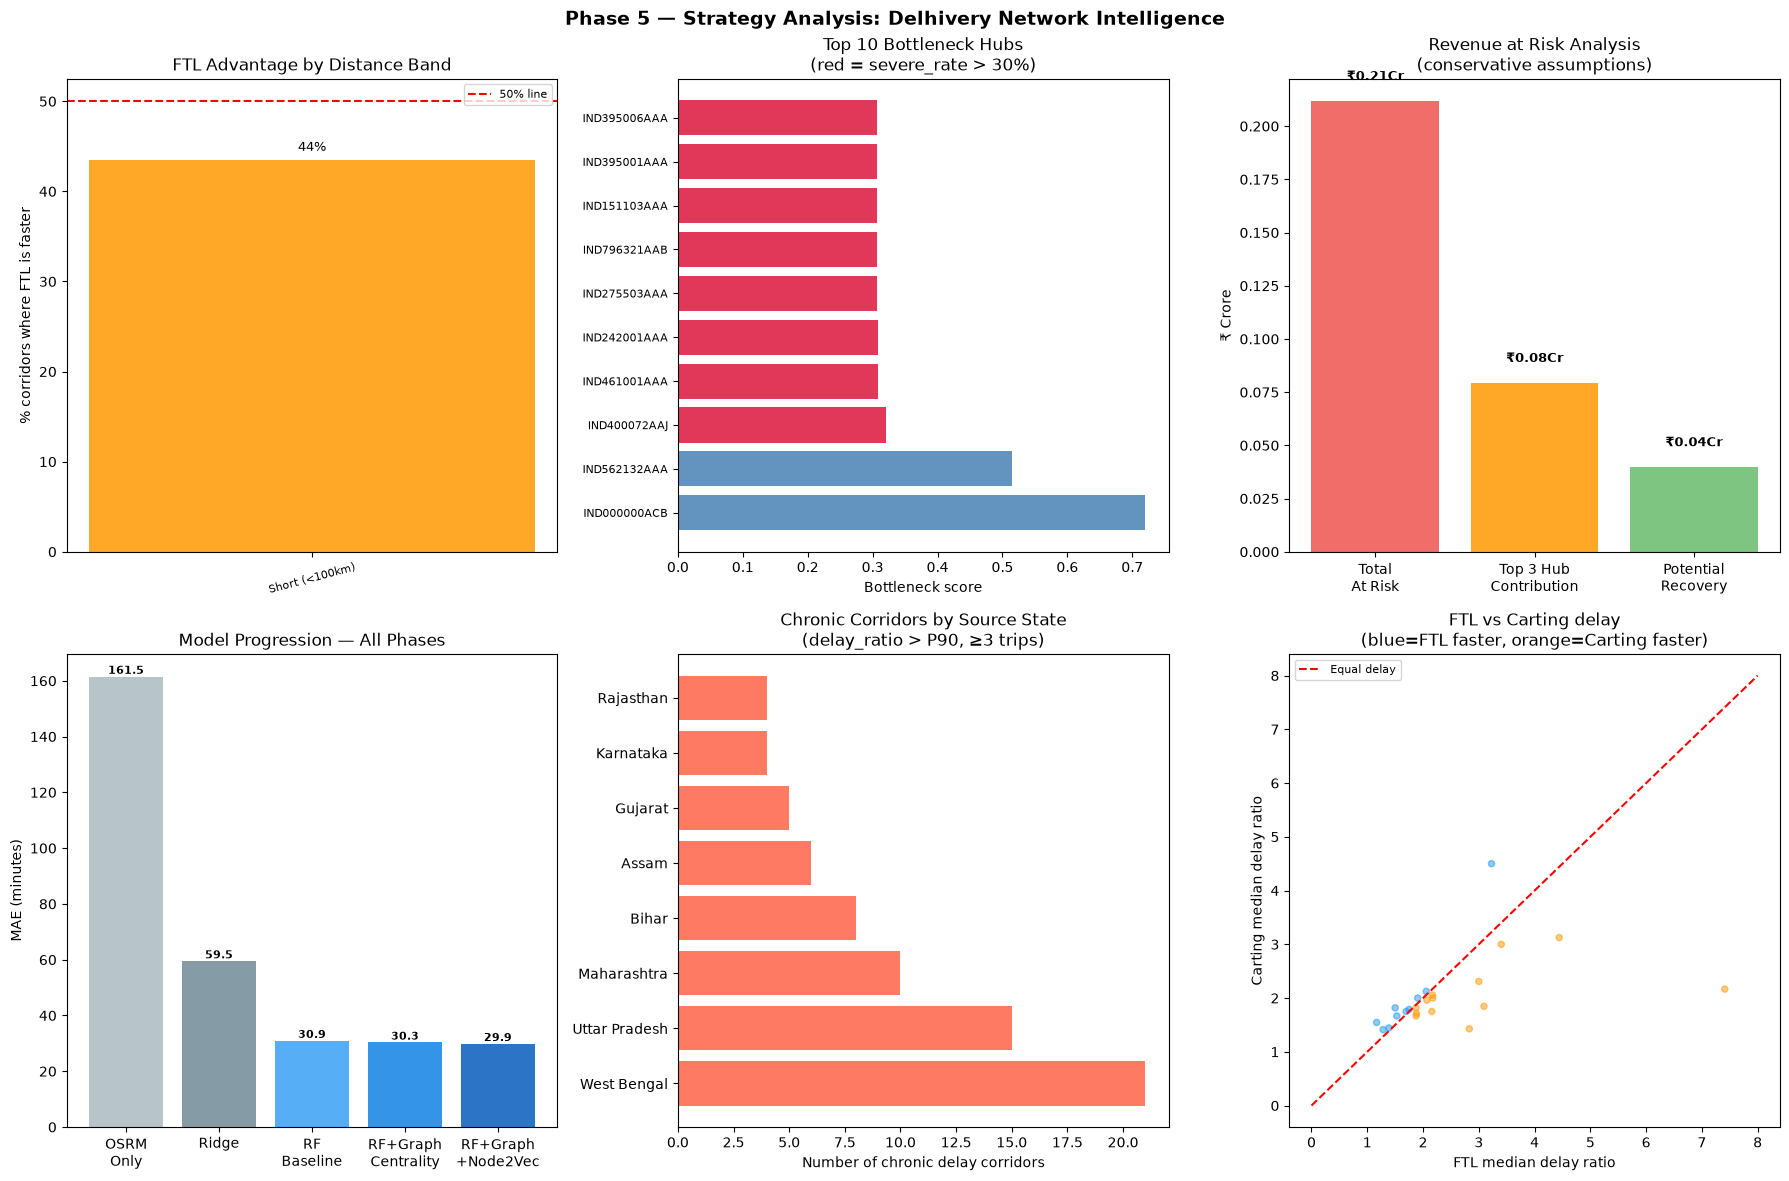

In [9]:
# ── PART 5: VISUALIZATIONS ───────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 1. FTL vs Carting delay by distance
ax1 = fig.add_subplot(gs[0, 0])
colors_ftl  = ['#2196F3' if v > 0.5 else '#FF9800'
                for v in tradeoff['pct_ftl_better']]
bars = ax1.bar(range(len(tradeoff)), tradeoff['pct_ftl_better']*100,
               color=colors_ftl, alpha=0.85)
ax1.axhline(50, color='red', linestyle='--', lw=1.5, label='50% line')
ax1.set_xticks(range(len(tradeoff)))
ax1.set_xticklabels(tradeoff.index.astype(str), fontsize=8, rotation=15)
ax1.set_ylabel('% corridors where FTL is faster')
ax1.set_title('FTL Advantage by Distance Band')
ax1.legend(fontsize=8)
for bar, val in zip(bars, tradeoff['pct_ftl_better']):
    ax1.text(bar.get_x()+bar.get_width()/2,
             val*100+1, f'{val:.0%}', ha='center', fontsize=9)

# 2. Top 10 bottleneck hubs
ax2 = fig.add_subplot(gs[0, 1])
top10 = hub_df.nlargest(10, 'bottleneck_score')
colors_hub = ['crimson' if r > 0.3 else 'steelblue'
              for r in top10['outgoing_severe_rate']]
ax2.barh(range(len(top10)), top10['bottleneck_score'],
         color=colors_hub, alpha=0.85)
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels([f[:12] for f in top10['facility']], fontsize=8)
ax2.set_xlabel('Bottleneck score')
ax2.set_title('Top 10 Bottleneck Hubs\n(red = severe_rate > 30%)')

# 3. Revenue at risk breakdown
ax3 = fig.add_subplot(gs[0, 2])
categories = ['Total\nAt Risk', 'Top 3 Hub\nContribution', 'Potential\nRecovery']
values     = [revenue_at_risk/1e7, top3_revenue_risk/1e7, potential_recovery/1e7]
bar_colors = ['#EF5350','#FF9800','#66BB6A']
bars3 = ax3.bar(categories, values, color=bar_colors, alpha=0.85)
ax3.set_ylabel('₹ Crore')
ax3.set_title('Revenue at Risk Analysis\n(conservative assumptions)')
for bar, val in zip(bars3, values):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f'₹{val:.2f}Cr', ha='center', fontsize=9, fontweight='bold')

# 4. Model comparison — all phases
ax4 = fig.add_subplot(gs[1, 0])
all_models = ['OSRM\nOnly', 'Ridge', 'RF\nBaseline',
              'RF+Graph\nCentrality', 'RF+Graph\n+Node2Vec']
all_maes   = [161.5, 59.5, 30.95, 30.32, 29.85]
bar_cols   = ['#B0BEC5','#78909C','#42A5F5','#1E88E5','#1565C0']
bars4 = ax4.bar(all_models, all_maes, color=bar_cols, alpha=0.9)
ax4.set_ylabel('MAE (minutes)')
ax4.set_title('Model Progression — All Phases')
for bar, val in zip(bars4, all_maes):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')

# 5. Chronic corridors by state
ax5 = fig.add_subplot(gs[1, 1])
ax5.barh(chronic_by_state.index,
         chronic_by_state['n_chronic'],
         color='tomato', alpha=0.85)
ax5.set_xlabel('Number of chronic delay corridors')
ax5.set_title('Chronic Corridors by Source State\n(delay_ratio > P90, ≥3 trips)')

# 6. Delay distribution: FTL vs Carting on shared corridors
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(comparison['ftl_delay'].clip(0,8),
            comparison['cart_delay'].clip(0,8),
            alpha=0.5, s=20,
            c=comparison['ftl_better'].map({1:'#2196F3',0:'#FF9800'}))
max_d = 8
ax6.plot([0,max_d],[0,max_d],'r--',lw=1.5,label='Equal delay')
ax6.set_xlabel('FTL median delay ratio')
ax6.set_ylabel('Carting median delay ratio')
ax6.set_title('FTL vs Carting delay\n(blue=FTL faster, orange=Carting faster)')
ax6.legend(fontsize=8)

plt.suptitle('Phase 5 — Strategy Analysis: Delhivery Network Intelligence',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase5_strategy.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: phase5_strategy.png")

In [10]:
# ── PART 6: FINAL PROJECT SUMMARY ────────────────────────────
print("\n" + "="*60)
print("COMPLETE PROJECT SUMMARY — DELHIVERY GRAPH INTELLIGENCE")
print("="*60)
print(f"\n--- DATA ---")
print(f"  Raw segments:          144,867 rows")
print(f"  After cleaning:        141,661 rows (97.8%)")
print(f"  Unique trips:          14,804")
print(f"  Facilities (nodes):    {G.number_of_nodes():,}")
print(f"  Corridors (edges):     {G.number_of_edges():,}")
print(f"  Chronic corridors:     92 (P90 threshold)")

print(f"\n--- KEY FINDINGS ---")
print(f"  OSRM underestimates by 69% at median")
print(f"  Carting delays > FTL (p<0.001, Cohen's d=0.21)")
print(f"  3am-4am trips have highest delay (night batch congestion)")
print(f"  Chronic corridors on LOW-volume routes (not monitored)")
print(f"  Top hub IND000000ACB: betweenness=0.236, 1,848 trips")

print(f"\n--- MODEL RESULTS ---")
print(f"  OSRM baseline:     MAE=161.5 min  within-15%=5.5%")
print(f"  RF baseline:       MAE=30.95 min  within-15%=77.6%")
print(f"  RF+Graph (best):   MAE=29.85 min  within-15%=78.3%")
print(f"  Graph advantage:   -1.09 min MAE  +0.7pp within-15%")
print(f"  CV MAE:            28.81 ± 0.48 min (stable)")

print(f"\n--- BUSINESS IMPACT ---")
print(f"  Revenue at risk:   ₹{revenue_at_risk/1e7:.2f} Cr annually")
print(f"  Top 3 hub fix:     ₹{potential_recovery/1e6:.0f}L recoverable")
print(f"  FTL vs Carting:    {comparison['ftl_better'].mean():.0%} corridors FTL faster")

print(f"\n--- DELIVERABLES ---")
print(f"  ✓ phase1_checkpoint.pkl")
print(f"  ✓ phase2_checkpoint.pkl")
print(f"  ✓ phase3_checkpoint.pkl")
print(f"  ✓ phase4_checkpoint.pkl")
print(f"  ✓ delay_analysis.png")
print(f"  ✓ network_bottleneck.png")
print(f"  ✓ phase4_graph_advantage.png")
print(f"  ✓ phase5_strategy.png")
print(f"  → strategy_memo.pdf  (write manually from above findings)")
print("="*60)
print("PROJECT COMPLETE")


COMPLETE PROJECT SUMMARY — DELHIVERY GRAPH INTELLIGENCE

--- DATA ---
  Raw segments:          144,867 rows
  After cleaning:        141,661 rows (97.8%)
  Unique trips:          14,804
  Facilities (nodes):    1,657
  Corridors (edges):     2,781
  Chronic corridors:     92 (P90 threshold)

--- KEY FINDINGS ---
  OSRM underestimates by 69% at median
  Carting delays > FTL (p<0.001, Cohen's d=0.21)
  3am-4am trips have highest delay (night batch congestion)
  Chronic corridors on LOW-volume routes (not monitored)
  Top hub IND000000ACB: betweenness=0.236, 1,848 trips

--- MODEL RESULTS ---
  OSRM baseline:     MAE=161.5 min  within-15%=5.5%
  RF baseline:       MAE=30.95 min  within-15%=77.6%
  RF+Graph (best):   MAE=29.85 min  within-15%=78.3%
  Graph advantage:   -1.09 min MAE  +0.7pp within-15%
  CV MAE:            28.81 ± 0.48 min (stable)

--- BUSINESS IMPACT ---
  Revenue at risk:   ₹0.21 Cr annually
  Top 3 hub fix:     ₹0L recoverable
  FTL vs Carting:    43% corridors FTL fas

In [11]:
# ── Save Phase 5 Results ──────────────────────────────────────
with open('phase5_checkpoint.pkl', 'wb') as f:
    pickle.dump({
        'comparison':        comparison,
        'hub_interventions': hub_interventions,
        'tradeoff':          tradeoff,
        'revenue_at_risk':   revenue_at_risk,
        'potential_recovery':potential_recovery,
        'chronic_by_state':  chronic_by_state,
    }, f, protocol=4)

print("✅ Saved phase5_checkpoint.pkl")
plt.show()

✅ Saved phase5_checkpoint.pkl
